In [17]:
# Importando as bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- CÓDIGO CORRIGIDO PARA O SEU AMBIENTE LOCAL ---

# Nomes dos arquivos que você tem na sua pasta
arquivo_principal_csv = 'consolidado_filtrado_nomes_descritivos.csv'
arquivo_dicionario_excel = 'Dicionario_PNAD_COVID_112020_20220621.xls'

try:
    # 1. Carrega a base de dados principal a partir do arquivo CSV
    df = pd.read_csv(arquivo_principal_csv)

    # 2. Carrega o dicionário a partir do arquivo Excel (.xls)
    # Pandas pode carregar planilhas (abas) diferentes de um mesmo arquivo Excel.
    # Vamos carregar cada aba em um dataframe separado.
    dicionario_variaveis = pd.read_excel(arquivo_dicionario_excel, sheet_name='dicionário pnad covid')
    dicionario_atividades = pd.read_excel(arquivo_dicionario_excel, sheet_name='Planilha1')


    print("--- Arquivos carregados com SUCESSO! ---")
    print("\nAs 5 primeiras linhas da sua base de dados:")
    print(df.head())

    print("\nAs 5 primeiras linhas do dicionário de variáveis (da 1ª aba do Excel):")
    print(dicionario_variaveis.head())
    
    print("\nAs 5 primeiras linhas do dicionário de atividades (da 2ª aba do Excel):")
    print(dicionario_atividades.head())


except FileNotFoundError:
    print(f"ERRO: Arquivo não encontrado!")
    print(f"Verifique se os arquivos '{arquivo_principal_csv}' E '{arquivo_dicionario_excel}'")
    print("estão EXATAMENTE NA MESMA PASTA onde o seu Jupyter Notebook está salvo.")

except Exception as e:
    print(f"Ocorreu um erro inesperado: {e}")
    print("DICA: Se o erro mencionar 'xlrd', você precisa instalar uma biblioteca.")
    print("Abra o terminal/prompt e execute o comando: pip install xlrd")

--- Arquivos carregados com SUCESSO! ---

As 5 primeiras linhas da sua base de dados:
    Ano    Mes  UF  CAPITAL  Cor ou raça  Escolaridade  Este domicílio é  \
0  2020  Junho  11     11.0            4             5                 1   
1  2020  Junho  11     11.0            4             7                 1   
2  2020  Junho  11     11.0            4             2                 1   
3  2020  Junho  11     11.0            4             2                 1   
4  2020  Junho  11     11.0            1             2                 1   

   Na semana passada teve dificuldade para respirar?  \
0                                                  2   
1                                                  2   
2                                                  2   
3                                                  2   
4                                                  2   

   Na semana passada teve dor de cabeça?  \
0                                      2   
1                               

In [18]:
# --- Bloco 2 (Versão Melhorada e Segura) ---
# Mapeando os valores de 'Sexo'
# Primeiro, verificamos se a coluna ainda é numérica
if pd.api.types.is_numeric_dtype(df['Sexo']):
    df['Sexo'] = df['Sexo'].map({1: 'Homem', 2: 'Mulher'})
    print("Coluna 'Sexo' foi mapeada.")
else:
    print("Coluna 'Sexo' já parece ter sido mapeada. Pulando.")

# Mapeando os valores de 'Cor ou raça'
if pd.api.types.is_numeric_dtype(df['Cor ou raça']):
    cor_raca_map = {1: 'Branca', 2: 'Preta', 3: 'Amarela', 4: 'Parda', 5: 'Indígena', 9: 'Ignorado'}
    df['Cor ou raça'] = df['Cor ou raça'].map(cor_raca_map)
    print("Coluna 'Cor ou raça' foi mapeada.")
else:
    print("Coluna 'Cor ou raça' já parece ter sido mapeada. Pulando.")

# Mapeando os valores de 'Escolaridade'
if pd.api.types.is_numeric_dtype(df['Escolaridade']):
    escolaridade_map = {
        1: 'Sem instrução e fundamental incompleto',
        2: 'Fundamental completo e médio incompleto',
        3: 'Médio completo e superior incompleto',
        4: 'Superior completo',
        5: 'Não aplicável'
    }
    df['Escolaridade'] = df['Escolaridade'].map(escolaridade_map)
    print("Coluna 'Escolaridade' foi mapeada.")
else:
    print("Coluna 'Escolaridade' já parece ter sido mapeada. Pulando.")

# Mapeando as respostas de "Sim" ou "Não" para as colunas de sintomas
sintomas_cols = [
    'Na semana passada teve dificuldade para respirar?',
    'Na semana passada teve dor de cabeça?',
    'Na semana passada teve dor de garganta?',
    'Na semana passada teve febre?',
    'Na semana passada teve perda de cheiro ou sabor?',
    'Na semana passada teve tosse?'
]

# Vamos mapear apenas a primeira coluna de sintoma para verificar, para não poluir a saída
primeira_coluna_sintoma = sintomas_cols[0]
if pd.api.types.is_numeric_dtype(df[primeira_coluna_sintoma]):
    for col in sintomas_cols:
        df[col] = df[col].map({1: 'Sim', 2: 'Não'})
    print("Colunas de sintomas foram mapeadas.")
else:
    print("Colunas de sintomas já parecem ter sido mapeadas. Pulando.")

# Visualizando o resultado final para confirmar
print("\n--- Resultado da Limpeza ---")
print(df.head())

Coluna 'Sexo' foi mapeada.
Coluna 'Cor ou raça' foi mapeada.
Coluna 'Escolaridade' foi mapeada.
Colunas de sintomas foram mapeadas.

--- Resultado da Limpeza ---
    Ano    Mes  UF  CAPITAL Cor ou raça  \
0  2020  Junho  11     11.0       Parda   
1  2020  Junho  11     11.0       Parda   
2  2020  Junho  11     11.0       Parda   
3  2020  Junho  11     11.0       Parda   
4  2020  Junho  11     11.0      Branca   

                              Escolaridade  Este domicílio é  \
0                            Não aplicável                 1   
1                                      NaN                 1   
2  Fundamental completo e médio incompleto                 1   
3  Fundamental completo e médio incompleto                 1   
4  Fundamental completo e médio incompleto                 1   

  Na semana passada teve dificuldade para respirar?  \
0                                               Não   
1                                               Não   
2                            

C:\Users\manzi\AppData\Local\Temp\ipykernel_33064\7282919.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequência', y='Sintoma', data=df_sintomas, palette='viridis')


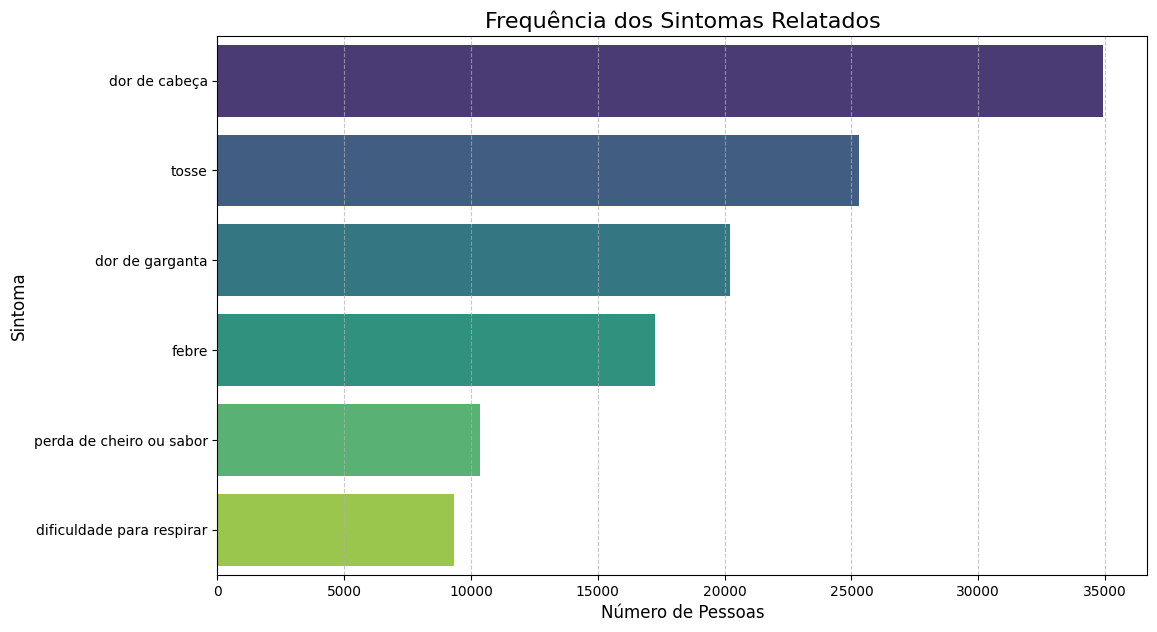

In [19]:
# --- Bloco 3.1: Características Clínicas dos Sintomas ---

# Lista das colunas de sintomas que já limpamos
sintomas_cols = [
    'Na semana passada teve dificuldade para respirar?',
    'Na semana passada teve dor de cabeça?',
    'Na semana passada teve dor de garganta?',
    'Na semana passada teve febre?',
    'Na semana passada teve perda de cheiro ou sabor?',
    'Na semana passada teve tosse?'
]

# Dicionário para guardar a contagem de cada sintoma
sintomas_freq = {}

# Loop para contar a frequência de "Sim" para cada sintoma
for col in sintomas_cols:
    frequencia = df[col].value_counts().get('Sim', 0)
    # Vamos usar um nome mais curto para o gráfico para ficar mais legível
    nome_sintoma = col.replace('Na semana passada teve ', '').replace('?', '')
    sintomas_freq[nome_sintoma] = frequencia

# Criando um novo DataFrame com os resultados para facilitar a criação do gráfico
df_sintomas = pd.DataFrame(list(sintomas_freq.items()), columns=['Sintoma', 'Frequência'])
df_sintomas = df_sintomas.sort_values(by='Frequência', ascending=False)

# Gerando o gráfico de barras
plt.figure(figsize=(12, 7))
sns.barplot(x='Frequência', y='Sintoma', data=df_sintomas, palette='viridis')
plt.title('Frequência dos Sintomas Relatados', fontsize=16)
plt.xlabel('Número de Pessoas', fontsize=12)
plt.ylabel('Sintoma', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Exibindo o gráfico
plt.show()

C:\Users\manzi\AppData\Local\Temp\ipykernel_33064\1758053071.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\manzi\AppData\Local\Temp\ipykernel_33064\1758053071.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


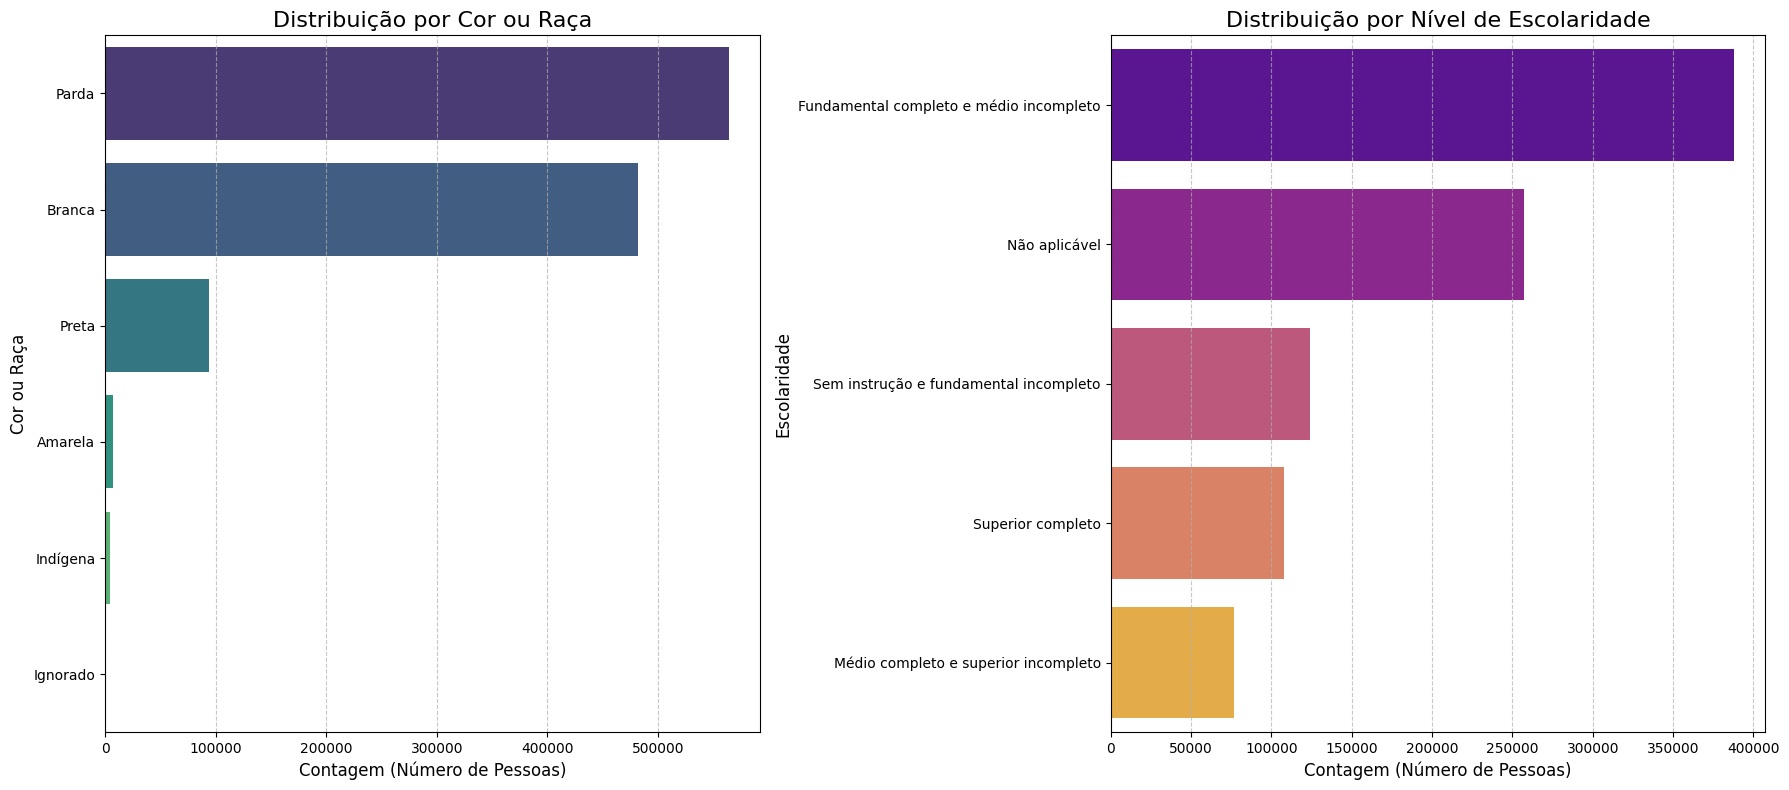

In [20]:
# --- Bloco 3.2 (Versão Melhorada com Gráficos de Barras) ---

# Criando a figura que vai conter nossos dois gráficos
plt.figure(figsize=(18, 8))

# --- Gráfico de Cor ou Raça ---

# Posição 1 (1 linha, 2 colunas, 1º gráfico)
plt.subplot(1, 2, 1)

# Usando o countplot do Seaborn para criar o gráfico de barras horizontais
# O parâmetro 'order' ordena as barras da mais frequente para a menos frequente
sns.countplot(
    y='Cor ou raça',
    data=df,
    palette='viridis',
    order=df['Cor ou raça'].value_counts().index # Ordena as barras
)
plt.title('Distribuição por Cor ou Raça', fontsize=16)
plt.xlabel('Contagem (Número de Pessoas)', fontsize=12)
plt.ylabel('Cor ou Raça', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)


# --- Gráfico de Escolaridade ---

# Posição 2 (1 linha, 2 colunas, 2º gráfico)
plt.subplot(1, 2, 2)
sns.countplot(
    y='Escolaridade',
    data=df,
    palette='plasma',
    order=df['Escolaridade'].value_counts().index # Ordena as barras
)
plt.title('Distribuição por Nível de Escolaridade', fontsize=16)
plt.xlabel('Contagem (Número de Pessoas)', fontsize=12)
plt.ylabel('Escolaridade', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Ajusta o layout para garantir que não haja sobreposição de texto
plt.tight_layout()

# Exibe os gráficos
plt.show()

--- Porcentagem de pessoas com 'Dificuldade para Respirar' por Escolaridade ---
Na semana passada teve dificuldade para respirar?       Sim
Escolaridade                                               
Não aplicável                                      0.957602
Médio completo e superior incompleto               0.863066
Superior completo                                  0.819962
Fundamental completo e médio incompleto            0.699089
Sem instrução e fundamental incompleto             0.511550


C:\Users\manzi\AppData\Local\Temp\ipykernel_33064\4280336250.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


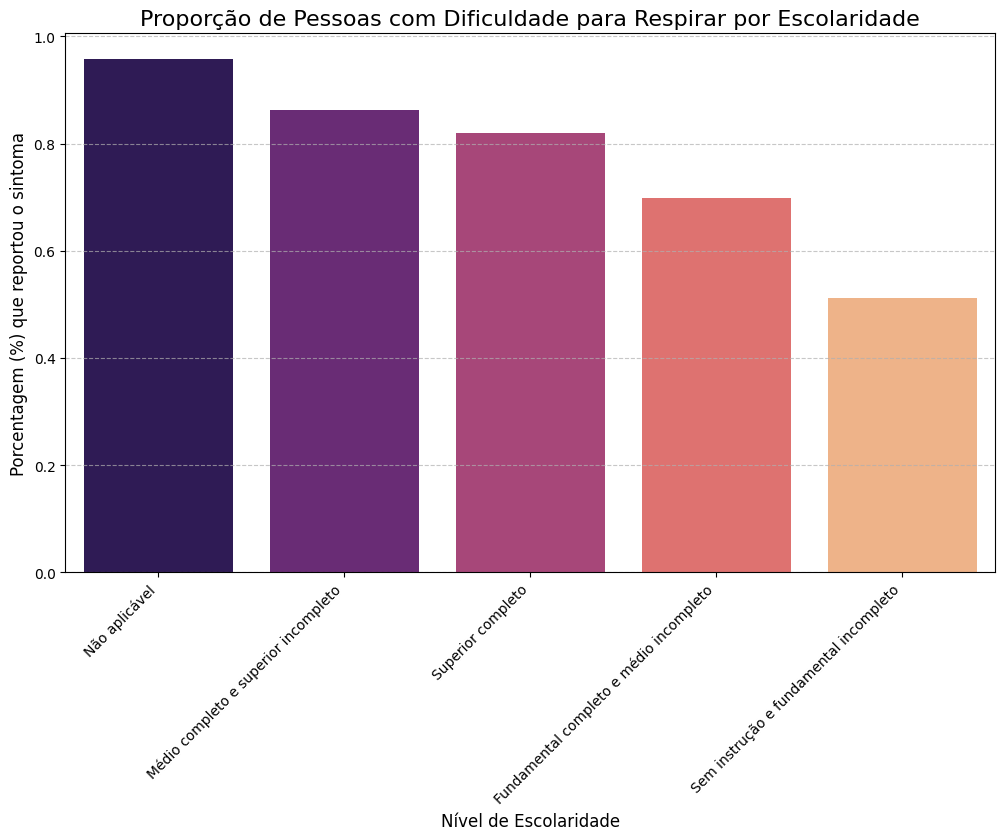

In [21]:
# --- Insight 1: Prevalência de 'Dificuldade para respirar' por Escolaridade ---

# Criando uma tabela de contingência com proporções
# 'normalize='index'' calcula a porcentagem em cada linha (em cada nível de escolaridade)
tabela_esc_sintoma = pd.crosstab(
    index=df['Escolaridade'],
    columns=df['Na semana passada teve dificuldade para respirar?'],
    normalize='index'
)

# Multiplicamos por 100 para ter a porcentagem
tabela_esc_sintoma = tabela_esc_sintoma * 100

# Vamos focar apenas na coluna 'Sim' e ordenar
tabela_esc_sintoma = tabela_esc_sintoma[['Sim']].sort_values(by='Sim', ascending=False)

print("--- Porcentagem de pessoas com 'Dificuldade para Respirar' por Escolaridade ---")
print(tabela_esc_sintoma)


# Gerando o gráfico
plt.figure(figsize=(12, 7))
sns.barplot(
    x=tabela_esc_sintoma.index,
    y=tabela_esc_sintoma['Sim'],
    palette='magma'
)

plt.title('Proporção de Pessoas com Dificuldade para Respirar por Escolaridade', fontsize=16)
plt.xlabel('Nível de Escolaridade', fontsize=12)
plt.ylabel('Porcentagem (%) que reportou o sintoma', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotaciona os labels do eixo x para não sobrepor
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Coluna de Auxílio Emergencial foi mapeada.

--- Porcentagem de pessoas que receberam Auxílio Emergencial por Cor/Raça ---
Recebeu algum auxílio emergencial?        Sim
Cor ou raça                                  
Amarela                             96.826526
Ignorado                            96.218487
Branca                              95.882641
Preta                               95.323125
Parda                               94.944403
Indígena                            94.411631


C:\Users\manzi\AppData\Local\Temp\ipykernel_33064\4094008984.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


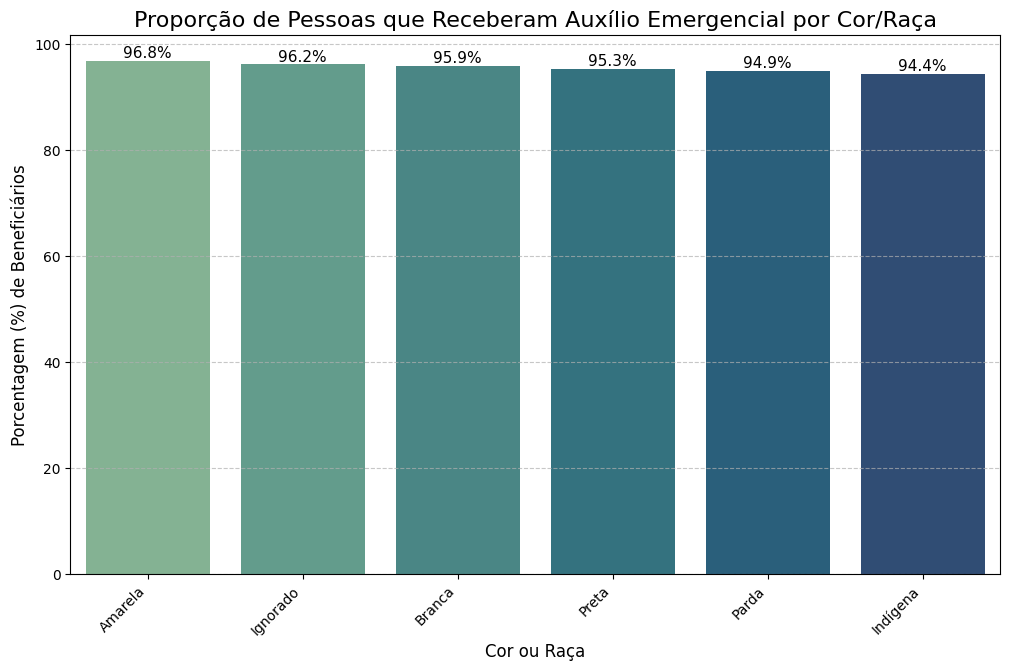

In [22]:
# --- Insight 2: Proporção de Recebimento de Auxílio Emergencial por Cor/Raça ---

# Passo 1: Garantir que a coluna do auxílio está mapeada (código de segurança)
coluna_auxilio = 'Recebeu algum auxílio emergencial?'

if pd.api.types.is_numeric_dtype(df[coluna_auxilio]):
    df[coluna_auxilio] = df[coluna_auxilio].map({1: 'Sim', 2: 'Não'})
    print("Coluna de Auxílio Emergencial foi mapeada.")
else:
    print("Coluna de Auxílio Emergencial já parece ter sido mapeada. Pulando.")


# Passo 2: Criar a tabela de contingência com as proporções
tabela_auxilio_raca = pd.crosstab(
    index=df['Cor ou raça'],
    columns=df[coluna_auxilio],
    normalize='index'  # Calcula a porcentagem por linha (dentro de cada grupo de Cor/Raça)
)

# Multiplicar por 100 para ter o valor em porcentagem
tabela_auxilio_raca = tabela_auxilio_raca * 100

# Passo 3: Preparar os dados para o gráfico
# Vamos focar apenas na coluna 'Sim' e ordenar do maior para o menor
tabela_auxilio_raca = tabela_auxilio_raca[['Sim']].sort_values(by='Sim', ascending=False)

print("\n--- Porcentagem de pessoas que receberam Auxílio Emergencial por Cor/Raça ---")
print(tabela_auxilio_raca)


# Passo 4: Gerar o gráfico de barras
plt.figure(figsize=(12, 7))
sns.barplot(
    x=tabela_auxilio_raca.index,
    y=tabela_auxilio_raca['Sim'],
    palette='crest'
)

plt.title('Proporção de Pessoas que Receberam Auxílio Emergencial por Cor/Raça', fontsize=16)
plt.xlabel('Cor ou Raça', fontsize=12)
plt.ylabel('Porcentagem (%) de Beneficiários', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os rótulos de porcentagem em cima das barras para maior clareza
for index, value in enumerate(tabela_auxilio_raca['Sim']):
    plt.text(index, value + 0.5, f'{value:.1f}%', ha='center', fontsize=11)

plt.show()

Coluna de Sintoma já parece ter sido mapeada. Pulando.

--- Porcentagem de pessoas que relataram 'Dor de Cabeça' por Estado ---
Na semana passada teve dor de cabeça?       Sim
Estado                                         
Acre                                   5.223654
Amapá                                  5.222972
Roraima                                5.106326
Paraíba                                4.377896
Sergipe                                3.935843


C:\Users\manzi\AppData\Local\Temp\ipykernel_33064\743614300.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


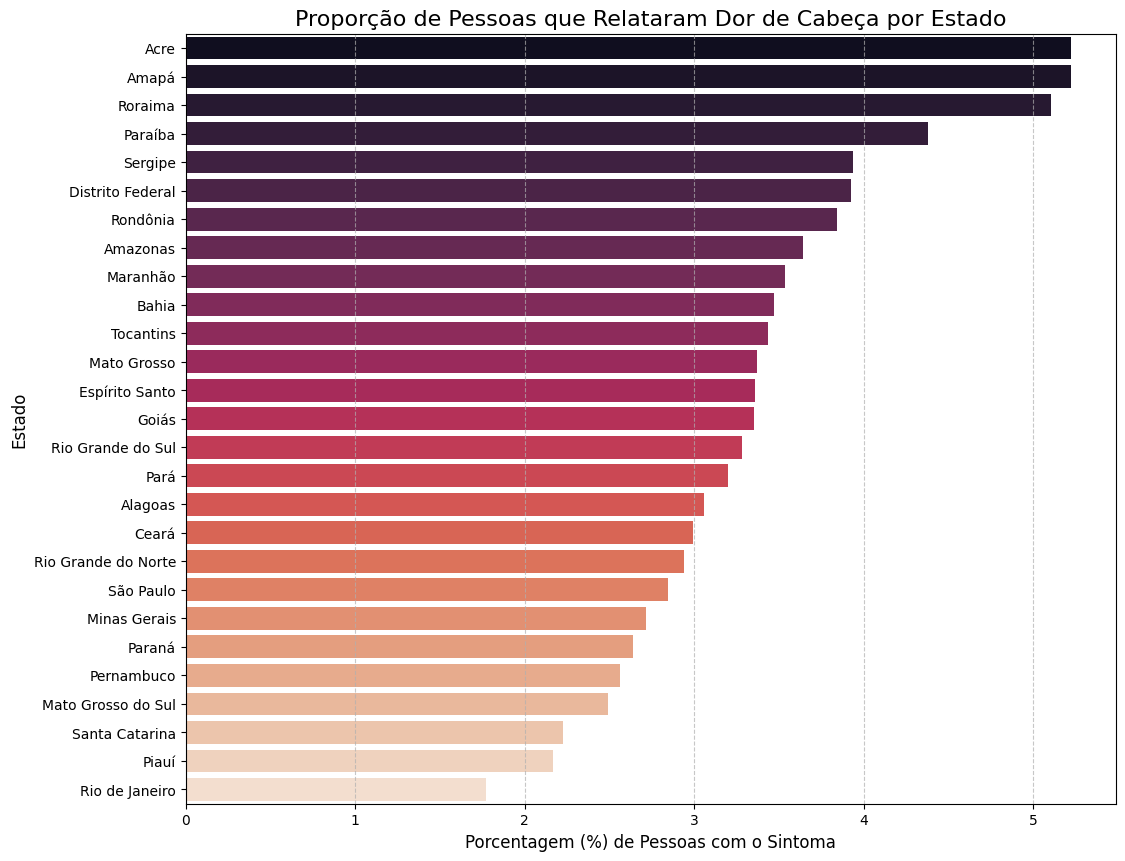

In [23]:
# --- Insight 3: Prevalência de 'Dor de Cabeça' por Unidade da Federação (UF) ---

# Passo 1: Criar um dicionário para mapear o código da UF para o nome do estado
# Essas informações estão no dicionário da PNAD que carregamos no início
uf_map = {
    11: 'Rondônia', 12: 'Acre', 13: 'Amazonas', 14: 'Roraima', 15: 'Pará', 16: 'Amapá', 17: 'Tocantins',
    21: 'Maranhão', 22: 'Piauí', 23: 'Ceará', 24: 'Rio Grande do Norte', 25: 'Paraíba', 26: 'Pernambuco',
    27: 'Alagoas', 28: 'Sergipe', 29: 'Bahia',
    31: 'Minas Gerais', 32: 'Espírito Santo', 33: 'Rio de Janeiro', 35: 'São Paulo',
    41: 'Paraná', 42: 'Santa Catarina', 43: 'Rio Grande do Sul',
    50: 'Mato Grosso do Sul', 51: 'Mato Grosso', 52: 'Goiás', 53: 'Distrito Federal'
}

# Criamos uma nova coluna 'Estado' no DataFrame com os nomes já mapeados
df['Estado'] = df['UF'].map(uf_map)


# Passo 2: Garantir que a coluna do sintoma está mapeada
sintoma_analisado = 'Na semana passada teve dor de cabeça?'
if pd.api.types.is_numeric_dtype(df[sintoma_analisado]):
    df[sintoma_analisado] = df[sintoma_analisado].map({1: 'Sim', 2: 'Não'})
    print("Coluna de Sintoma foi mapeada.")
else:
    print("Coluna de Sintoma já parece ter sido mapeada. Pulando.")


# Passo 3: Calcular a proporção do sintoma por Estado
tabela_sintoma_uf = pd.crosstab(
    index=df['Estado'],
    columns=df[sintoma_analisado],
    normalize='index' # Normaliza por linha (por Estado)
) * 100

# Focamos na coluna 'Sim' e ordenamos para o gráfico ficar mais claro
tabela_sintoma_uf = tabela_sintoma_uf[['Sim']].sort_values(by='Sim', ascending=False)

print("\n--- Porcentagem de pessoas que relataram 'Dor de Cabeça' por Estado ---")
print(tabela_sintoma_uf.head()) # Mostra os 5 primeiros


# Passo 4: Gerar o gráfico de barras horizontais
# Um gráfico horizontal é essencial aqui por causa da quantidade de estados
plt.figure(figsize=(12, 10))
sns.barplot(
    x=tabela_sintoma_uf['Sim'],
    y=tabela_sintoma_uf.index,
    palette='rocket'
)

plt.title('Proporção de Pessoas que Relataram Dor de Cabeça por Estado', fontsize=16)
plt.xlabel('Porcentagem (%) de Pessoas com o Sintoma', fontsize=12)
plt.ylabel('Estado', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

Coluna 'Região' criada com sucesso.

--- Porcentagem de pessoas que relataram 'Dor de Cabeça' por Região ---
Na semana passada teve dor de cabeça?       Sim
Região                                         
Norte                                  4.017017
Centro-Oeste                           3.263007
Nordeste                               3.219979
Sul                                    2.708020
Sudeste                                2.600043


C:\Users\manzi\AppData\Local\Temp\ipykernel_33064\873244091.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


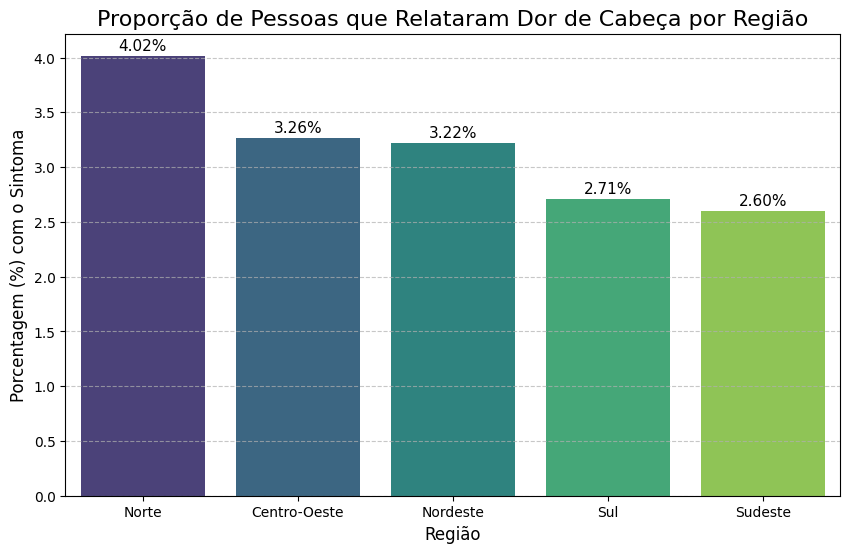

In [24]:
# --- Insight 3.1: Agrupando a Prevalência de 'Dor de Cabeça' por Região ---

# Passo 1: Criar o dicionário que mapeia cada Estado para sua respectiva Região
regiao_map = {
    # Norte
    'Rondônia': 'Norte', 'Acre': 'Norte', 'Amazonas': 'Norte', 'Roraima': 'Norte',
    'Pará': 'Norte', 'Amapá': 'Norte', 'Tocantins': 'Norte',
    # Nordeste
    'Maranhão': 'Nordeste', 'Piauí': 'Nordeste', 'Ceará': 'Nordeste',
    'Rio Grande do Norte': 'Nordeste', 'Paraíba': 'Nordeste', 'Pernambuco': 'Nordeste',
    'Alagoas': 'Nordeste', 'Sergipe': 'Nordeste', 'Bahia': 'Nordeste',
    # Sudeste
    'Minas Gerais': 'Sudeste', 'Espírito Santo': 'Sudeste', 'Rio de Janeiro': 'Sudeste',
    'São Paulo': 'Sudeste',
    # Sul
    'Paraná': 'Sul', 'Santa Catarina': 'Sul', 'Rio Grande do Sul': 'Sul',
    # Centro-Oeste
    'Mato Grosso do Sul': 'Centro-Oeste', 'Mato Grosso': 'Centro-Oeste',
    'Goiás': 'Centro-Oeste', 'Distrito Federal': 'Centro-Oeste'
}

# Passo 2: Criar a nova coluna 'Região' no DataFrame
# Certifique-se de que a coluna 'Estado' já existe (ela foi criada no passo anterior)
if 'Estado' in df.columns:
    df['Região'] = df['Estado'].map(regiao_map)
    print("Coluna 'Região' criada com sucesso.")
else:
    print("ERRO: A coluna 'Estado' não foi encontrada. Execute o código do insight anterior primeiro.")


# Passo 3: Calcular a proporção do sintoma por Região
sintoma_analisado = 'Na semana passada teve dor de cabeça?'

tabela_sintoma_regiao = pd.crosstab(
    index=df['Região'],
    columns=df[sintoma_analisado],
    normalize='index' # Normaliza por Região
) * 100

# Focamos na coluna 'Sim' e ordenamos
tabela_sintoma_regiao = tabela_sintoma_regiao[['Sim']].sort_values(by='Sim', ascending=False)

print("\n--- Porcentagem de pessoas que relataram 'Dor de Cabeça' por Região ---")
print(tabela_sintoma_regiao)


# Passo 4: Gerar o gráfico de barras para as Regiões
plt.figure(figsize=(10, 6))
sns.barplot(
    x=tabela_sintoma_regiao.index,
    y=tabela_sintoma_regiao['Sim'],
    palette='viridis'
)

plt.title('Proporção de Pessoas que Relataram Dor de Cabeça por Região', fontsize=16)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Porcentagem (%) com o Sintoma', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os rótulos de porcentagem
for index, value in enumerate(tabela_sintoma_regiao['Sim']):
    plt.text(index, value + 0.05, f'{value:.2f}%', ha='center', fontsize=11)

plt.show()

Coluna 'Na semana passada teve dificuldade para respirar?' já parece ter sido mapeada. Pulando.

--- Porcentagem de pessoas que relataram 'Na semana passada teve dificuldade para respirar?' por Região ---
Na semana passada teve dificuldade para respirar?       Sim
Região                                                     
Norte                                              1.408745
Centro-Oeste                                       0.892761
Sudeste                                            0.730890
Nordeste                                           0.711993
Sul                                                0.672025


C:\Users\manzi\AppData\Local\Temp\ipykernel_33064\612743317.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


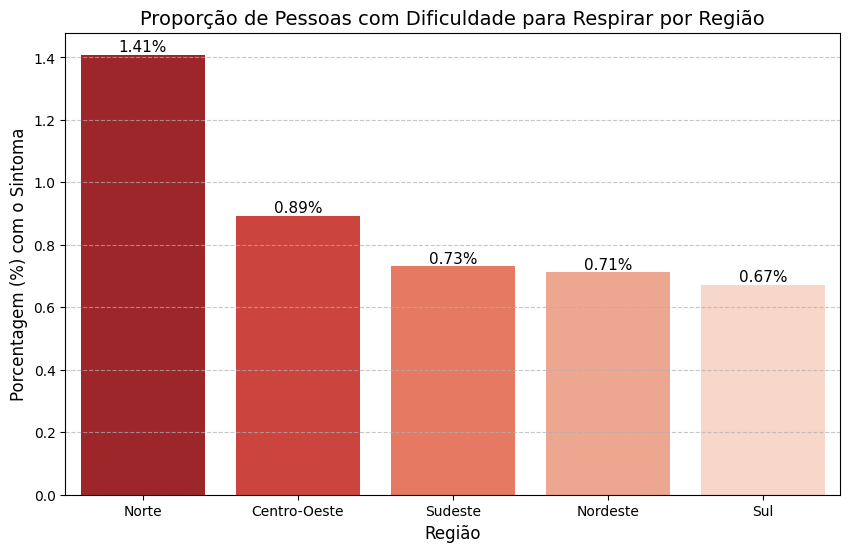

In [25]:
# --- Análise Regional para "Dificuldade para Respirar" ---

# Coluna do sintoma que vamos analisar agora
sintoma_analisado = 'Na semana passada teve dificuldade para respirar?'

# Garantir que a coluna do sintoma está mapeada
if pd.api.types.is_numeric_dtype(df[sintoma_analisado]):
    df[sintoma_analisado] = df[sintoma_analisado].map({1: 'Sim', 2: 'Não'})
    print(f"Coluna '{sintoma_analisado}' foi mapeada.")
else:
    print(f"Coluna '{sintoma_analisado}' já parece ter sido mapeada. Pulando.")

# Calcular a proporção do sintoma por Região
tabela_sintoma_regiao = pd.crosstab(
    index=df['Região'],
    columns=df[sintoma_analisado],
    normalize='index'
) * 100

tabela_sintoma_regiao = tabela_sintoma_regiao[['Sim']].sort_values(by='Sim', ascending=False)

print(f"\n--- Porcentagem de pessoas que relataram '{sintoma_analisado}' por Região ---")
print(tabela_sintoma_regiao)

# Gerar o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(
    x=tabela_sintoma_regiao.index,
    y=tabela_sintoma_regiao['Sim'],
    palette='Reds_r' # Usando uma paleta de cores diferente
)

plt.title(f'Proporção de Pessoas com Dificuldade para Respirar por Região', fontsize=14)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Porcentagem (%) com o Sintoma', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar rótulos
for index, value in enumerate(tabela_sintoma_regiao['Sim']):
    plt.text(index, value + 0.01, f'{value:.2f}%', ha='center', fontsize=11)

plt.show()

Coluna 'Na semana passada teve perda de cheiro ou sabor?' já parece ter sido mapeada. Pulando.

--- Porcentagem de pessoas que relataram 'Na semana passada teve perda de cheiro ou sabor?' por Região ---
Na semana passada teve perda de cheiro ou sabor?       Sim
Região                                                    
Norte                                             1.845629
Nordeste                                          1.107049
Centro-Oeste                                      0.923283
Sudeste                                           0.571559
Sul                                               0.459033


C:\Users\manzi\AppData\Local\Temp\ipykernel_33064\1260480968.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


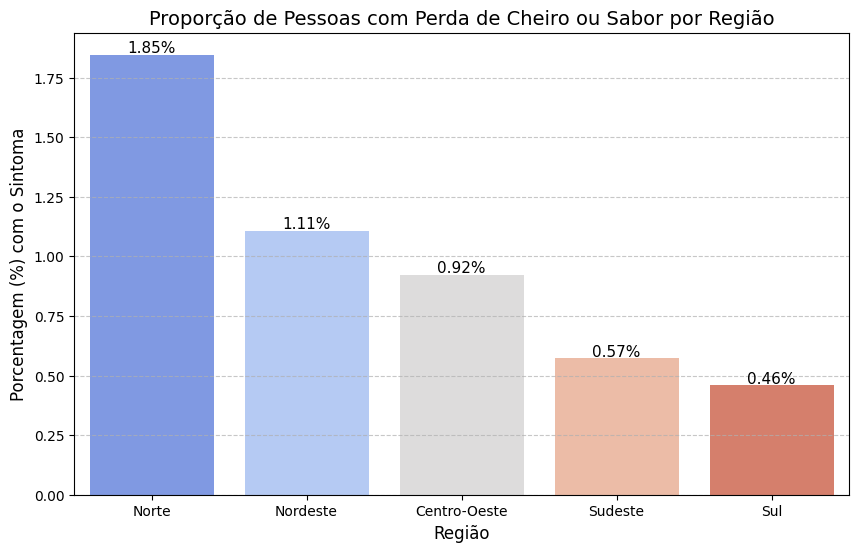

In [26]:
# --- Análise Regional para "Perda de Cheiro ou Sabor" ---

# Coluna do sintoma que vamos analisar agora
sintoma_analisado = 'Na semana passada teve perda de cheiro ou sabor?'

# Garantir que a coluna do sintoma está mapeada
if pd.api.types.is_numeric_dtype(df[sintoma_analisado]):
    df[sintoma_analisado] = df[sintoma_analisado].map({1: 'Sim', 2: 'Não'})
    print(f"Coluna '{sintoma_analisado}' foi mapeada.")
else:
    print(f"Coluna '{sintoma_analisado}' já parece ter sido mapeada. Pulando.")

# Calcular a proporção do sintoma por Região
tabela_sintoma_regiao = pd.crosstab(
    index=df['Região'],
    columns=df[sintoma_analisado],
    normalize='index'
) * 100

tabela_sintoma_regiao = tabela_sintoma_regiao[['Sim']].sort_values(by='Sim', ascending=False)

print(f"\n--- Porcentagem de pessoas que relataram '{sintoma_analisado}' por Região ---")
print(tabela_sintoma_regiao)

# Gerar o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(
    x=tabela_sintoma_regiao.index,
    y=tabela_sintoma_regiao['Sim'],
    palette='coolwarm' # Usando outra paleta de cores
)

plt.title(f'Proporção de Pessoas com Perda de Cheiro ou Sabor por Região', fontsize=14)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Porcentagem (%) com o Sintoma', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar rótulos
for index, value in enumerate(tabela_sintoma_regiao['Sim']):
    plt.text(index, value + 0.01, f'{value:.2f}%', ha='center', fontsize=11)

plt.show()

Coluna 'Tem carteira de trabalho assinada ou é funcionário público estatutário?' foi mapeada.

--- Porcentagem de trabalhadores SEM carteira assinada (informais) por Região ---
Tem carteira de trabalho assinada ou é funcionário público estatutário?        Não
Região                                                                            
Norte                                                                    34.726062
Nordeste                                                                 28.803638
Centro-Oeste                                                             21.036924
Sul                                                                      15.870322
Sudeste                                                                  15.143503


C:\Users\manzi\AppData\Local\Temp\ipykernel_33064\2883626651.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


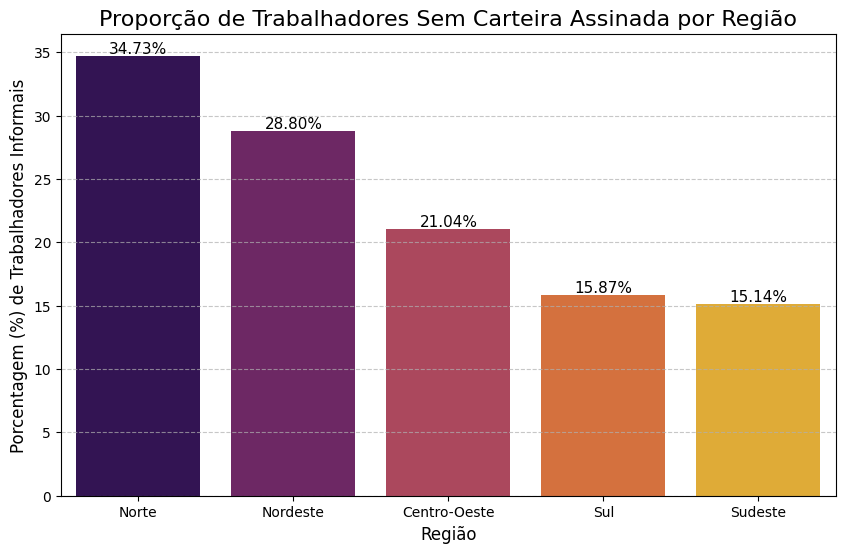

In [27]:
# --- Análise Final: Proporção de Trabalhadores Sem Carteira Assinada por Região ---

# Coluna que vamos analisar
coluna_trabalho = 'Tem carteira de trabalho assinada ou é funcionário público estatutário?'

# Passo 1: Garantir que a coluna de trabalho está mapeada (código de segurança)
if pd.api.types.is_numeric_dtype(df[coluna_trabalho]):
    df[coluna_trabalho] = df[coluna_trabalho].map({1: 'Sim', 2: 'Não'})
    print(f"Coluna '{coluna_trabalho}' foi mapeada.")
else:
    print(f"Coluna '{coluna_trabalho}' já parece ter sido mapeada. Pulando.")

# Passo 2: Calcular a proporção de 'Sim' e 'Não' por Região
tabela_trabalho_regiao = pd.crosstab(
    index=df['Região'],
    columns=df[coluna_trabalho],
    normalize='index' # Normaliza por Região
) * 100

# Passo 3: Focar na coluna de interesse ('Não') e ordenar
# Queremos ver a proporção de pessoas SEM carteira assinada
tabela_trabalho_regiao = tabela_trabalho_regiao[['Não']].sort_values(by='Não', ascending=False)

print("\n--- Porcentagem de trabalhadores SEM carteira assinada (informais) por Região ---")
print(tabela_trabalho_regiao)

# Passo 4: Gerar o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(
    x=tabela_trabalho_regiao.index,
    y=tabela_trabalho_regiao['Não'],
    palette='inferno'
)

plt.title('Proporção de Trabalhadores Sem Carteira Assinada por Região', fontsize=16)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Porcentagem (%) de Trabalhadores Informais', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os rótulos de porcentagem
for index, value in enumerate(tabela_trabalho_regiao['Não']):
    plt.text(index, value + 0.2, f'{value:.2f}%', ha='center', fontsize=11)

plt.show()

Coluna 'Tem mais de um trabalho' foi mapeada.
Coluna 'Tem carteira de trabalho assinada ou é funcionário público estatutário?' já parece ter sido mapeada. Pulando.


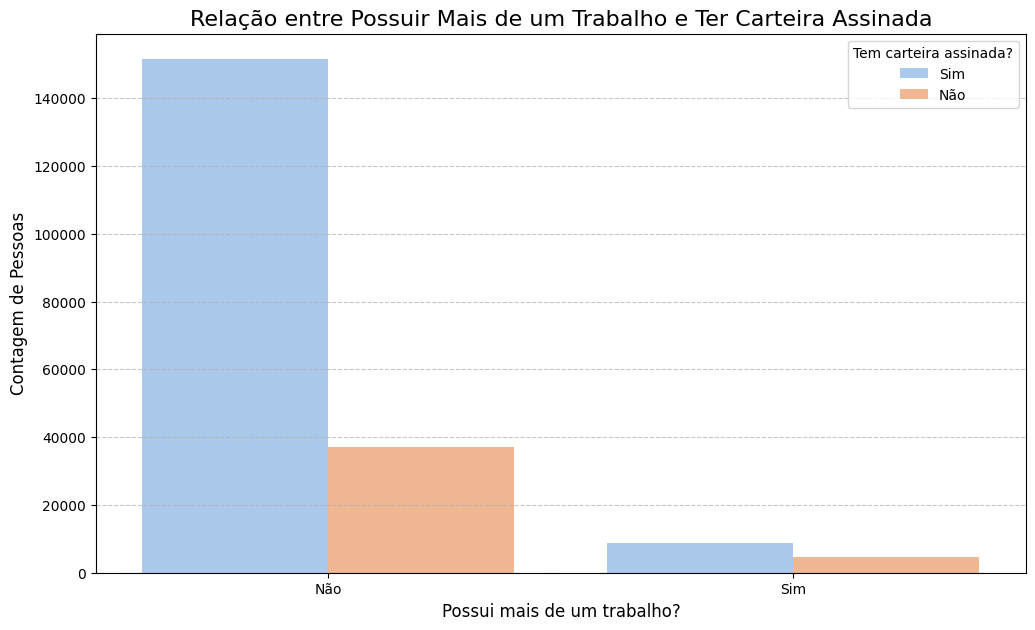

In [28]:
# --- Análise: Relação entre ter mais de um trabalho e informalidade ---

# Nomes das colunas que vamos usar
coluna_multitrabalho = 'Tem mais de um trabalho'
coluna_carteira = 'Tem carteira de trabalho assinada ou é funcionário público estatutário?'

# Passo 1: Garantir que as colunas estão mapeadas para 'Sim' e 'Não'
# (Código de segurança para evitar erros)
if pd.api.types.is_numeric_dtype(df[coluna_multitrabalho]):
    df[coluna_multitrabalho] = df[coluna_multitrabalho].map({1: 'Sim', 2: 'Não'})
    print(f"Coluna '{coluna_multitrabalho}' foi mapeada.")
else:
    print(f"Coluna '{coluna_multitrabalho}' já parece ter sido mapeada. Pulando.")

if pd.api.types.is_numeric_dtype(df[coluna_carteira]):
    df[coluna_carteira] = df[coluna_carteira].map({1: 'Sim', 2: 'Não'})
    print(f"Coluna '{coluna_carteira}' foi mapeada.")
else:
    print(f"Coluna '{coluna_carteira}' já parece ter sido mapeada. Pulando.")


# Passo 2: Gerar o gráfico de barras agrupado
plt.figure(figsize=(12, 7))
sns.countplot(
    x=coluna_multitrabalho,
    hue=coluna_carteira, # 'hue' separa as barras por cor com base nesta coluna
    data=df,
    palette='pastel'
)

plt.title('Relação entre Possuir Mais de um Trabalho e Ter Carteira Assinada', fontsize=16)
plt.xlabel('Possui mais de um trabalho?', fontsize=12)
plt.ylabel('Contagem de Pessoas', fontsize=12)
plt.legend(title='Tem carteira assinada?')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Coluna 'Na semana passada teve dor de garganta?' já parece ter sido mapeada. Pulando.

--- Porcentagem de pessoas que relataram 'Na semana passada teve dor de garganta?' por Região ---
Na semana passada teve dor de garganta?       Sim
Região                                           
Norte                                    2.689102
Centro-Oeste                             1.944731
Nordeste                                 1.877824
Sul                                      1.527513
Sudeste                                  1.343377


C:\Users\manzi\AppData\Local\Temp\ipykernel_33064\2237853018.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


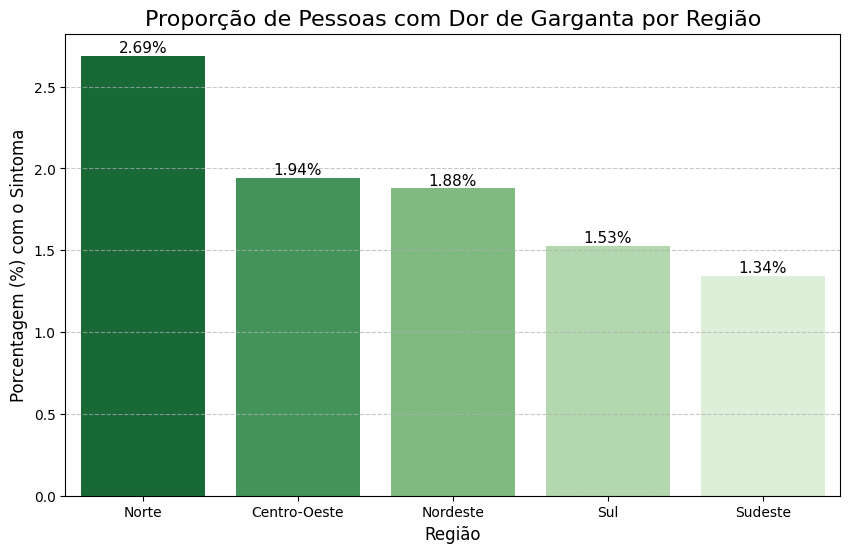

In [29]:
# --- Análise Regional para "Dor de Garganta" ---

# Coluna do sintoma que vamos analisar agora
sintoma_analisado = 'Na semana passada teve dor de garganta?'

# Garantir que a coluna do sintoma está mapeada
if pd.api.types.is_numeric_dtype(df[sintoma_analisado]):
    df[sintoma_analisado] = df[sintoma_analisado].map({1: 'Sim', 2: 'Não'})
    print(f"Coluna '{sintoma_analisado}' foi mapeada.")
else:
    print(f"Coluna '{sintoma_analisado}' já parece ter sido mapeada. Pulando.")

# Calcular a proporção do sintoma por Região
tabela_sintoma_regiao = pd.crosstab(
    index=df['Região'],
    columns=df[sintoma_analisado],
    normalize='index'
) * 100

tabela_sintoma_regiao = tabela_sintoma_regiao[['Sim']].sort_values(by='Sim', ascending=False)

print(f"\n--- Porcentagem de pessoas que relataram '{sintoma_analisado}' por Região ---")
print(tabela_sintoma_regiao)

# Gerar o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(
    x=tabela_sintoma_regiao.index,
    y=tabela_sintoma_regiao['Sim'],
    palette='Greens_r' # Paleta de Verdes
)

plt.title(f'Proporção de Pessoas com Dor de Garganta por Região', fontsize=16)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Porcentagem (%) com o Sintoma', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar rótulos
for index, value in enumerate(tabela_sintoma_regiao['Sim']):
    plt.text(index, value + 0.02, f'{value:.2f}%', ha='center', fontsize=11)

plt.show()

Coluna 'Na semana passada teve tosse?' já parece ter sido mapeada. Pulando.

--- Porcentagem de pessoas que relataram 'Na semana passada teve tosse?' por Região ---
Na semana passada teve tosse?       Sim
Região                                 
Norte                          2.923218
Centro-Oeste                   2.392080
Nordeste                       2.215274
Sudeste                        2.012581
Sul                            1.928581


C:\Users\manzi\AppData\Local\Temp\ipykernel_33064\1340338613.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


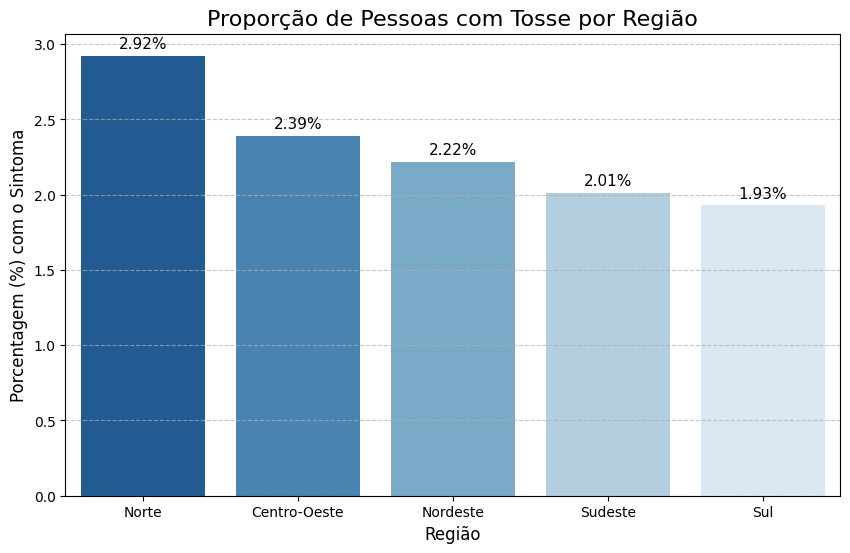

In [30]:
# --- Análise Regional para "Tosse" ---

# Coluna do sintoma que vamos analisar agora
sintoma_analisado = 'Na semana passada teve tosse?'

# Garantir que a coluna do sintoma está mapeada
if pd.api.types.is_numeric_dtype(df[sintoma_analisado]):
    df[sintoma_analisado] = df[sintoma_analisado].map({1: 'Sim', 2: 'Não'})
    print(f"Coluna '{sintoma_analisado}' foi mapeada.")
else:
    print(f"Coluna '{sintoma_analisado}' já parece ter sido mapeada. Pulando.")

# Calcular a proporção do sintoma por Região
tabela_sintoma_regiao = pd.crosstab(
    index=df['Região'],
    columns=df[sintoma_analisado],
    normalize='index'
) * 100

tabela_sintoma_regiao = tabela_sintoma_regiao[['Sim']].sort_values(by='Sim', ascending=False)

print(f"\n--- Porcentagem de pessoas que relataram '{sintoma_analisado}' por Região ---")
print(tabela_sintoma_regiao)

# Gerar o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(
    x=tabela_sintoma_regiao.index,
    y=tabela_sintoma_regiao['Sim'],
    palette='Blues_r' # Paleta de Azuis
)

plt.title(f'Proporção de Pessoas com Tosse por Região', fontsize=16)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Porcentagem (%) com o Sintoma', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar rótulos
for index, value in enumerate(tabela_sintoma_regiao['Sim']):
    plt.text(index, value + 0.05, f'{value:.2f}%', ha='center', fontsize=11)

plt.show()

Coluna 'Na semana passada teve febre?' já parece ter sido mapeada. Pulando.

--- Porcentagem de pessoas que relataram 'Na semana passada teve febre?' por Região ---
Na semana passada teve febre?       Sim
Região                                 
Norte                          2.832943
Nordeste                       1.937400
Centro-Oeste                   1.643012
Sudeste                        0.901034
Sul                            0.764468


C:\Users\manzi\AppData\Local\Temp\ipykernel_33064\3909774557.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


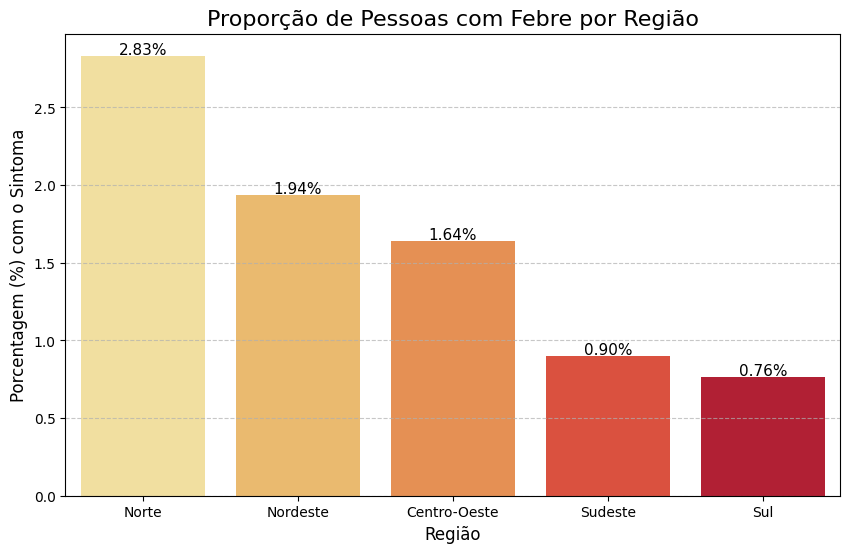

In [31]:
# --- Análise Regional para "Febre" ---

# Coluna do sintoma que vamos analisar agora
sintoma_analisado = 'Na semana passada teve febre?'

# Garantir que a coluna do sintoma está mapeada
if pd.api.types.is_numeric_dtype(df[sintoma_analisado]):
    df[sintoma_analisado] = df[sintoma_analisado].map({1: 'Sim', 2: 'Não'})
    print(f"Coluna '{sintoma_analisado}' foi mapeada.")
else:
    print(f"Coluna '{sintoma_analisado}' já parece ter sido mapeada. Pulando.")

# Calcular a proporção do sintoma por Região
tabela_sintoma_regiao = pd.crosstab(
    index=df['Região'],
    columns=df[sintoma_analisado],
    normalize='index'
) * 100

tabela_sintoma_regiao = tabela_sintoma_regiao[['Sim']].sort_values(by='Sim', ascending=False)

print(f"\n--- Porcentagem de pessoas que relataram '{sintoma_analisado}' por Região ---")
print(tabela_sintoma_regiao)

# Gerar o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(
    x=tabela_sintoma_regiao.index,
    y=tabela_sintoma_regiao['Sim'],
    palette='YlOrRd' # Paleta Amarelo/Laranja/Vermelho
)

plt.title(f'Proporção de Pessoas com Febre por Região', fontsize=16)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Porcentagem (%) com o Sintoma', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar rótulos
for index, value in enumerate(tabela_sintoma_regiao['Sim']):
    plt.text(index, value + 0.01, f'{value:.2f}%', ha='center', fontsize=11)

plt.show()

"Nossa análise revelou um padrão consistente onde a Região Norte apresentou a maior proporção de relatos de sintomas de COVID-19. Ao aprofundar a investigação, descobrimos uma possível explicação para este fenômeno: a mesma região também apresenta a maior taxa de informalidade no trabalho. Essa vulnerabilidade econômica pode ter levado a uma maior exposição da população ao vírus, resultando em um impacto mais severo da pandemia, o que se reflete nos dados de saúde."


--- Porcentagem de Domicílios Cedidos por Região ---
Tipo de Moradia Agrupado     Cedido
Região                             
Sudeste                   14.097534
Centro-Oeste              13.990760
Nordeste                  10.714072
Norte                     10.626878
Sul                        9.415530


C:\Users\manzi\AppData\Local\Temp\ipykernel_33064\2783954889.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


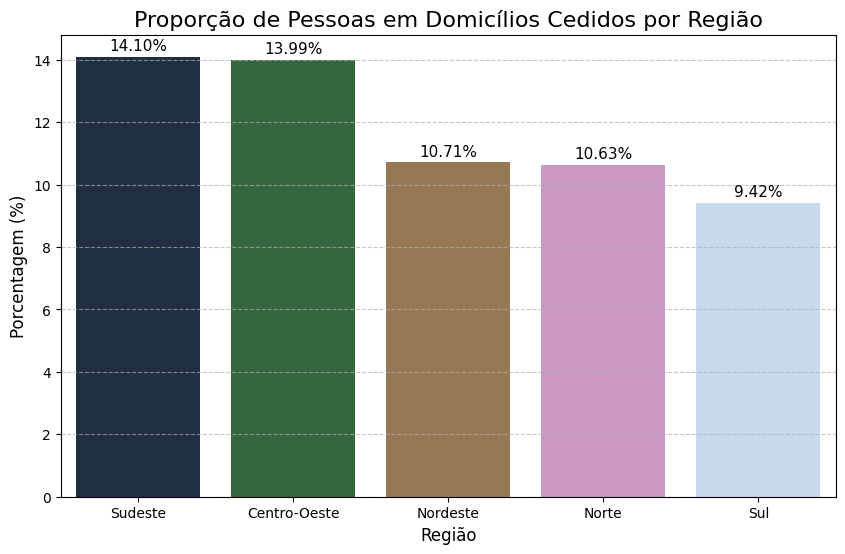

In [32]:
# --- Análise: Condição do Domicílio por Região ---

# Coluna que vamos analisar
coluna_domicilio = 'Este domicílio é'

# Passo 1: Mapear os códigos para nomes legíveis
# (Com base no dicionário da PNAD)
domicilio_map = {
    1: 'Próprio, já pago',
    2: 'Próprio, pagando',
    3: 'Alugado',
    4: 'Cedido por empregador',
    5: 'Cedido por familiar',
    6: 'Cedido de outra forma',
    7: 'Outra condição'
}
df['Condição do Domicílio'] = df[coluna_domicilio].map(domicilio_map)

# Agrupando as categorias 'Cedido' em uma só para simplificar
df['Tipo de Moradia Agrupado'] = df['Condição do Domicílio'].replace({
    'Cedido por empregador': 'Cedido',
    'Cedido por familiar': 'Cedido',
    'Cedido de outra forma': 'Cedido'
})

# Passo 2: Calcular a proporção de cada tipo de moradia por Região
tabela_moradia_regiao = pd.crosstab(
    index=df['Região'],
    columns=df['Tipo de Moradia Agrupado'],
    normalize='index' # Normaliza por Região
) * 100

# Passo 3: Focar na categoria 'Cedido' e ordenar
tabela_moradia_regiao = tabela_moradia_regiao[['Cedido']].sort_values(by='Cedido', ascending=False)

print("\n--- Porcentagem de Domicílios Cedidos por Região ---")
print(tabela_moradia_regiao)

# Passo 4: Gerar o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(
    x=tabela_moradia_regiao.index,
    y=tabela_moradia_regiao['Cedido'],
    palette='cubehelix'
)
plt.title('Proporção de Pessoas em Domicílios Cedidos por Região', fontsize=16)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Porcentagem (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for index, value in enumerate(tabela_moradia_regiao['Cedido']):
    plt.text(index, value + 0.2, f'{value:.2f}%', ha='center', fontsize=11)

plt.show()


--- Porcentagem de Beneficiários do Bolsa Família por Região ---
Recebe Bolsa Família        Sim
Região                         
Norte                 13.877301
Nordeste               9.958669
Centro-Oeste           5.695107
Sudeste                4.368763
Sul                    3.314979


C:\Users\manzi\AppData\Local\Temp\ipykernel_33064\3003177447.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


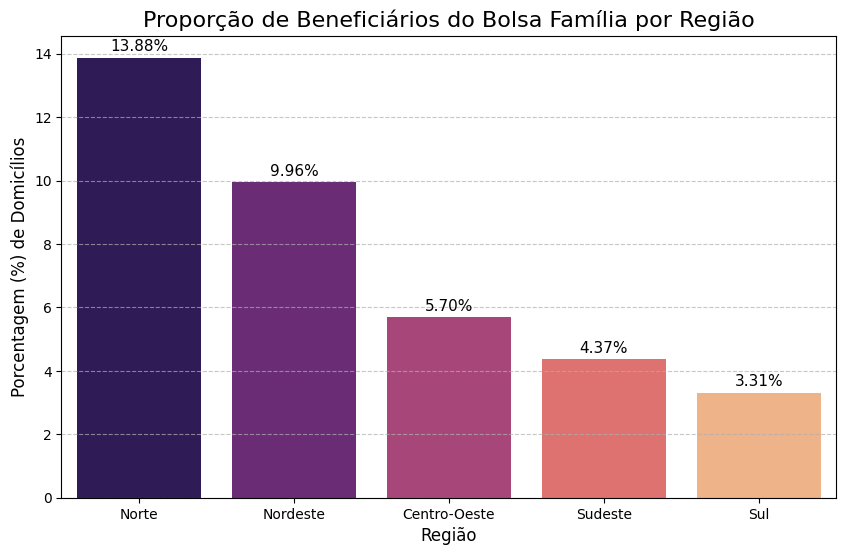

In [33]:
# --- Análise: Beneficiários do Bolsa Família por Região ---

# Coluna que vamos analisar
coluna_bolsa = 'Rendimentos de Programa Bolsa Família'

# Passo 1: Mapear a coluna (1=Recebe, 2=Não Recebe)
# Vamos criar uma nova coluna para não confundir
df['Recebe Bolsa Família'] = df[coluna_bolsa].map({1: 'Sim', 2: 'Não'})

# Passo 2: Calcular a proporção de beneficiários por Região
# Filtramos para não incluir valores nulos que podem distorcer o resultado
tabela_bolsa_regiao = pd.crosstab(
    index=df['Região'],
    columns=df['Recebe Bolsa Família'],
    normalize='index'
) * 100

# Passo 3: Focar na categoria 'Sim' e ordenar
tabela_bolsa_regiao = tabela_bolsa_regiao[['Sim']].sort_values(by='Sim', ascending=False)

print("\n--- Porcentagem de Beneficiários do Bolsa Família por Região ---")
print(tabela_bolsa_regiao)

# Passo 4: Gerar o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(
    x=tabela_bolsa_regiao.index,
    y=tabela_bolsa_regiao['Sim'],
    palette='magma'
)
plt.title('Proporção de Beneficiários do Bolsa Família por Região', fontsize=16)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Porcentagem (%) de Domicílios', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for index, value in enumerate(tabela_bolsa_regiao['Sim']):
    plt.text(index, value + 0.2, f'{value:.2f}%', ha='center', fontsize=11)

plt.show()

--- Proporção de cada tipo de Domicílio na Região Norte ---
       Tipo de Domicílio  Porcentagem
0       Próprio, já pago    74.164614
1                Alugado    11.778692
2    Cedido por familiar     7.666899
3       Próprio, pagando     3.144354
4  Cedido por empregador     1.960505
5  Cedido de outra forma     0.999473
6         Outra condição     0.285462


C:\Users\manzi\AppData\Local\Temp\ipykernel_33064\2719101531.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


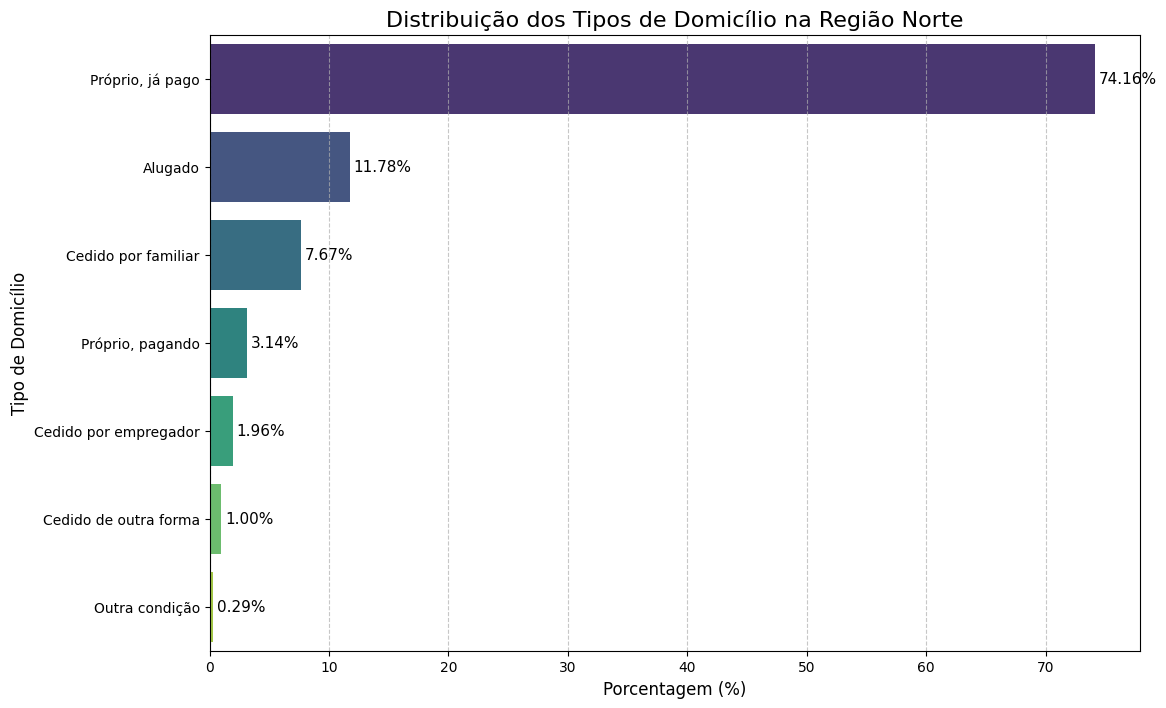

In [34]:
# --- Análise Detalhada: Tipos de Domicílio na Região Norte ---

# Passo 1: Filtrar o DataFrame para conter apenas dados da Região Norte
df_norte = df[df['Região'] == 'Norte'].copy()

# Passo 2: Calcular a proporção de cada tipo de domicílio para essa região
# Usamos a coluna 'Condição do Domicílio' que criamos anteriormente
# value_counts(normalize=True) já calcula a porcentagem (de 0 a 1)
proporcao_domicilios_norte = df_norte['Condição do Domicílio'].value_counts(normalize=True) * 100

# Converter para um DataFrame para facilitar a visualização e plotagem
df_proporcao_norte = proporcao_domicilios_norte.reset_index()
df_proporcao_norte.columns = ['Tipo de Domicílio', 'Porcentagem']


print("--- Proporção de cada tipo de Domicílio na Região Norte ---")
print(df_proporcao_norte)


# Passo 3: Gerar o gráfico de barras horizontais para visualizar
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Porcentagem',
    y='Tipo de Domicílio',
    data=df_proporcao_norte,
    palette='viridis'
)

plt.title('Distribuição dos Tipos de Domicílio na Região Norte', fontsize=16)
plt.xlabel('Porcentagem (%)', fontsize=12)
plt.ylabel('Tipo de Domicílio', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adicionar os rótulos de porcentagem nas barras
for index, value in enumerate(df_proporcao_norte['Porcentagem']):
    plt.text(value + 0.3, index, f'{value:.2f}%', va='center', fontsize=11)


plt.show()


--- Porcentagem de Pessoas em Faixas de Baixa Renda por Região ---
Renda Baixa         Sim
Região                 
Nordeste      75.620273
Norte         66.304325
Sudeste       56.331578
Centro-Oeste  52.870481
Sul           48.492325


C:\Users\manzi\AppData\Local\Temp\ipykernel_33064\2779605373.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


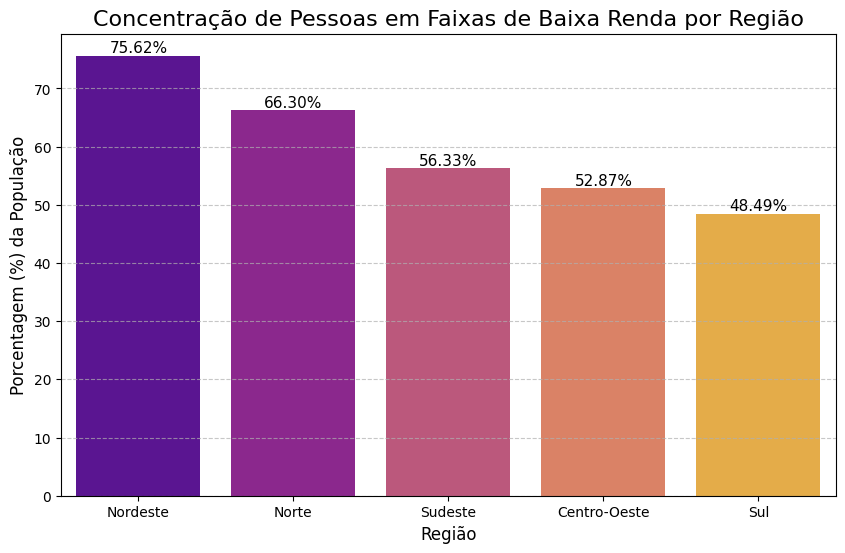

In [35]:
# --- Análise Final: Concentração de Pessoas de Baixa Renda por Região ---

# Coluna que vamos analisar
coluna_renda = 'Número da faixa do rendimento/retirada em dinheiro'

# Passo 1: Remover valores ausentes para uma análise precisa da renda
# O .dropna() remove linhas onde o valor de renda é nulo (NaN)
df_renda = df.dropna(subset=[coluna_renda]).copy()

# Passo 2: Definir o que é "Renda Baixa"
# Com base na estrutura da PNAD, as primeiras faixas representam os menores rendimentos.
# Vamos considerar as faixas até a 4ª como "Renda Baixa" para este exemplo.
limite_baixa_renda = 4.0
df_renda['Renda Baixa'] = df_renda[coluna_renda].apply(lambda x: 'Sim' if x <= limite_baixa_renda else 'Não')


# Passo 3: Calcular a proporção de pessoas com "Renda Baixa" por Região
tabela_renda_regiao = pd.crosstab(
    index=df_renda['Região'],
    columns=df_renda['Renda Baixa'],
    normalize='index' # Normaliza por Região
) * 100

# Passo 4: Focar na categoria 'Sim' e ordenar
tabela_renda_regiao = tabela_renda_regiao[['Sim']].sort_values(by='Sim', ascending=False)

print("\n--- Porcentagem de Pessoas em Faixas de Baixa Renda por Região ---")
print(tabela_renda_regiao)

# Passo 5: Gerar o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(
    x=tabela_renda_regiao.index,
    y=tabela_renda_regiao['Sim'],
    palette='plasma'
)
plt.title('Concentração de Pessoas em Faixas de Baixa Renda por Região', fontsize=16)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Porcentagem (%) da População', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for index, value in enumerate(tabela_renda_regiao['Sim']):
    plt.text(index, value + 0.5, f'{value:.2f}%', ha='center', fontsize=11)

plt.show()

Coluna 'Na semana passada teve perda de cheiro ou sabor?' já parece ter sido mapeada. Pulando.
Coluna 'Cor ou raça' já parece ter sido mapeada. Pulando.

--- Porcentagem de pessoas que relataram 'Na semana passada teve perda de cheiro ou sabor?' por Cor/Raça ---
Na semana passada teve perda de cheiro ou sabor?       Sim
Cor ou raça                                               
Ignorado                                          2.127660
Indígena                                          1.866606
Amarela                                           1.214806
Parda                                             1.064172
Preta                                             1.003459
Branca                                            0.690730


C:\Users\manzi\AppData\Local\Temp\ipykernel_33064\1184307375.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


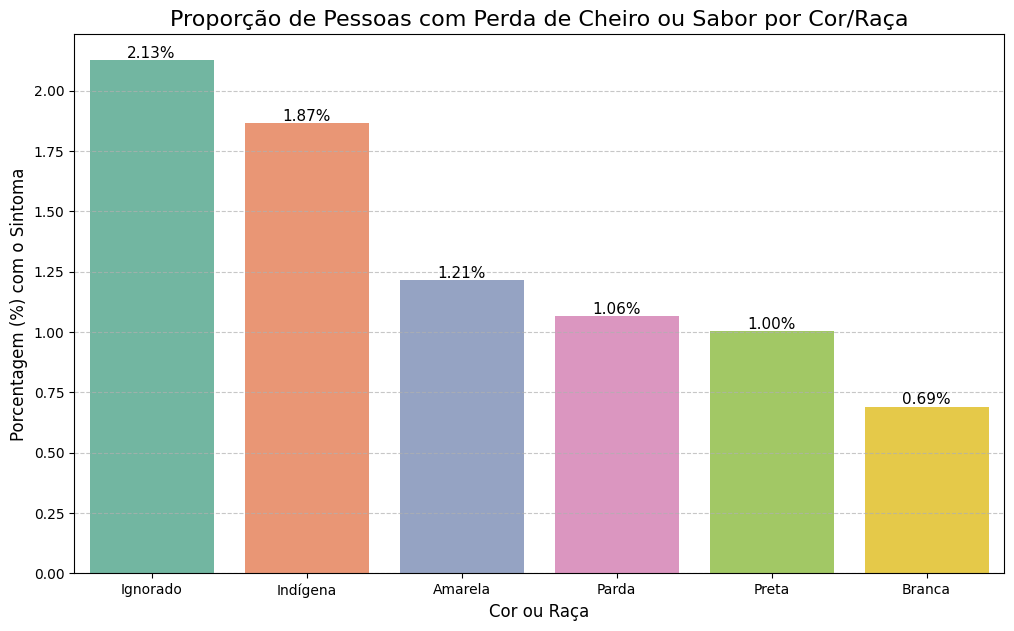

In [36]:
# --- Análise: Prevalência de 'Perda de Cheiro ou Sabor' por Cor/Raça ---

# Coluna do sintoma que vamos analisar
sintoma_analisado = 'Na semana passada teve perda de cheiro ou sabor?'

# Passo 1: Garantir que as colunas de sintoma e cor/raça estão mapeadas
if pd.api.types.is_numeric_dtype(df[sintoma_analisado]):
    df[sintoma_analisado] = df[sintoma_analisado].map({1: 'Sim', 2: 'Não'})
    print(f"Coluna '{sintoma_analisado}' foi mapeada.")
else:
    print(f"Coluna '{sintoma_analisado}' já parece ter sido mapeada. Pulando.")

if pd.api.types.is_numeric_dtype(df['Cor ou raça']):
    cor_raca_map = {1: 'Branca', 2: 'Preta', 3: 'Amarela', 4: 'Parda', 5: 'Indígena', 9: 'Ignorado'}
    df['Cor ou raça'] = df['Cor ou raça'].map(cor_raca_map)
    print("Coluna 'Cor ou raça' foi mapeada.")
else:
    print("Coluna 'Cor ou raça' já parece ter sido mapeada. Pulando.")

# Passo 2: Calcular a proporção do sintoma por Cor/Raça
tabela_sintoma_raca = pd.crosstab(
    index=df['Cor ou raça'],
    columns=df[sintoma_analisado],
    normalize='index' # Normaliza por linha (dentro de cada grupo)
) * 100

# Focamos na coluna 'Sim' e ordenamos
tabela_sintoma_raca = tabela_sintoma_raca[['Sim']].sort_values(by='Sim', ascending=False)

print(f"\n--- Porcentagem de pessoas que relataram '{sintoma_analisado}' por Cor/Raça ---")
print(tabela_sintoma_raca)

# Passo 3: Gerar o gráfico de barras
plt.figure(figsize=(12, 7))
sns.barplot(
    x=tabela_sintoma_raca.index,
    y=tabela_sintoma_raca['Sim'],
    palette='Set2'
)

plt.title(f'Proporção de Pessoas com Perda de Cheiro ou Sabor por Cor/Raça', fontsize=16)
plt.xlabel('Cor ou Raça', fontsize=12)
plt.ylabel('Porcentagem (%) com o Sintoma', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for index, value in enumerate(tabela_sintoma_raca['Sim']):
    plt.text(index, value + 0.01, f'{value:.2f}%', ha='center', fontsize=11)

plt.show()

--- Tabela com a taxa de Sintomas a cada 100 Pessoas ---
  Cor ou raça  Sintomas a cada 100 Pessoas
0    Indígena                    18.800539
1    Ignorado                    12.416107
2       Preta                    11.426119
3     Amarela                    11.392943
4       Parda                    10.974165
5      Branca                     8.937202


C:\Users\manzi\AppData\Local\Temp\ipykernel_33064\2460163845.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


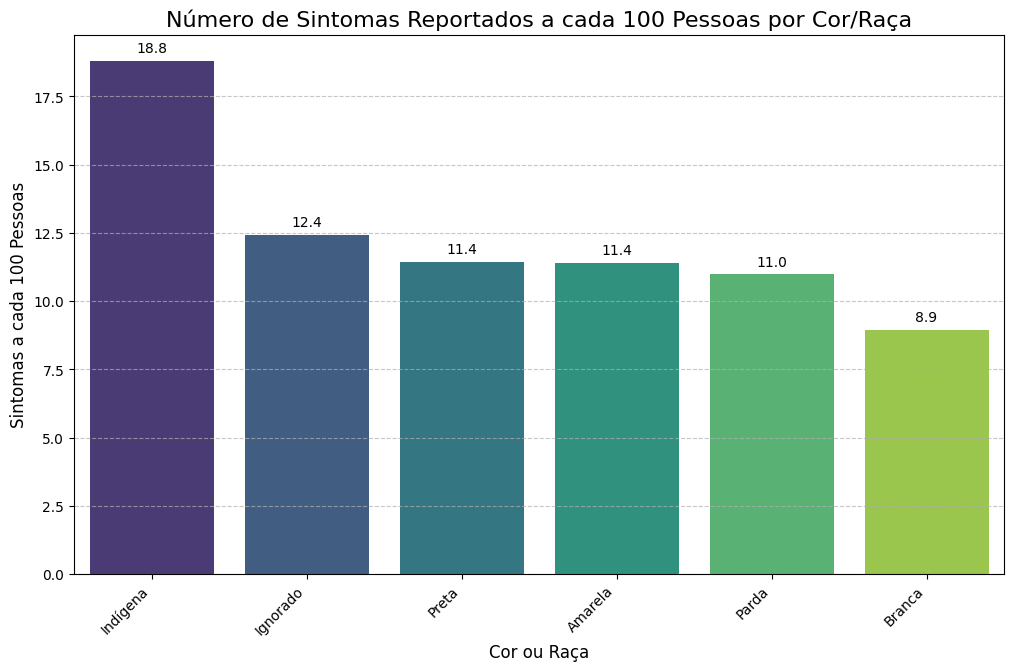

In [43]:
# --- Gráfico Final: Sintomas a cada 100 Pessoas por Cor/Raça ---

# Passo 1: Calcular a média e convertê-la para a escala "a cada 100 pessoas"
if 'df_para_soma' in locals():
    # Calcula a média (ex: 0.188)
    media_sintomas_raca = df_para_soma.groupby('Cor ou raça')['Total de Sintomas'].mean()
    
    # Multiplica por 100 para obter a taxa por 100 pessoas (ex: 18.8)
    sintomas_por_100 = (media_sintomas_raca * 100).sort_values(ascending=False)
    
    df_sintomas_100 = sintomas_por_100.reset_index()
    df_sintomas_100.columns = ['Cor ou raça', 'Sintomas a cada 100 Pessoas']

    print("--- Tabela com a taxa de Sintomas a cada 100 Pessoas ---")
    print(df_sintomas_100)

    # Passo 2: Gerar o gráfico de barras com a nova escala
    plt.figure(figsize=(12, 7))
    ax = sns.barplot(
        x='Cor ou raça',
        y='Sintomas a cada 100 Pessoas',
        data=df_sintomas_100,
        palette='viridis'
    )

    plt.title('Número de Sintomas Reportados a cada 100 Pessoas por Cor/Raça', fontsize=16)
    plt.xlabel('Cor ou Raça', fontsize=12)
    plt.ylabel('Sintomas a cada 100 Pessoas', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Adicionar os rótulos de dados (os valores) em cima de cada barra, formatados com 1 casa decimal
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.1f'), 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'center', 
                       xytext = (0, 9), 
                       textcoords = 'offset points')

    plt.show()

else:
    print("ERRO: O DataFrame 'df_para_soma' com o total de sintomas não foi encontrado.")
    print("Por favor, execute o bloco de código anterior (o do boxplot) primeiro para criar os dados necessários.")